<a href="https://colab.research.google.com/github/Manish-248/Deep-Learning-with-PyTorch-End-to-End-Pipeline/blob/main/Deep_Learning_with_PyTorch_End_to_End_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (150, 4)
NeuralNet(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=3, bias=True)
)
Epoch [10/50], Loss: 0.0893
Epoch [20/50], Loss: 0.0575
Epoch [30/50], Loss: 0.0520
Epoch [40/50], Loss: 0.0459
Epoch [50/50], Loss: 0.0706

Test Accuracy: 1.0


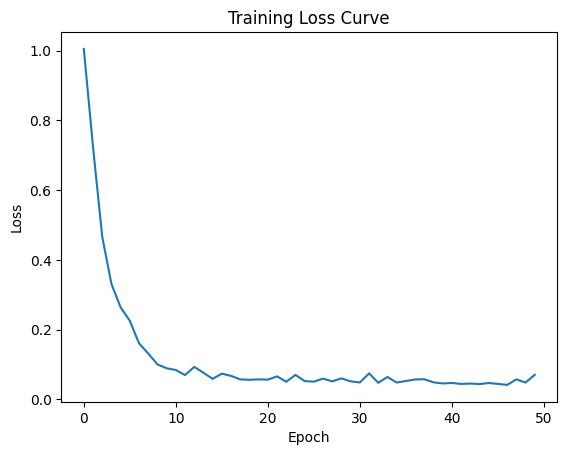


Model saved successfully!
Model loaded successfully!

Deep Learning Pipeline Completed 🚀


In [2]:
"""
================================================================================
NOTEBOOK 2: PyTorch Deep Learning Pipeline
Author: Manish Chandra

Description:
This notebook demonstrates a complete deep learning workflow using PyTorch:
- Data Loading (Iris Dataset)
- Data Preprocessing
- Neural Network Design
- Training & Validation
- Performance Evaluation
- Visualization
- Model Saving & Loading

================================================================================
"""

# ==============================================================================
# 📌 1. IMPORT LIBRARIES
# ==============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 📌 2. LOAD REAL DATASET (IRIS)
# ==============================================================================

iris = load_iris()
X = iris.data
y = iris.target

print("Dataset shape:", X.shape)

# ==============================================================================
# 📌 3. DATA PREPROCESSING
# ==============================================================================

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for NN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# ==============================================================================
# 📌 4. DATA LOADER
# ==============================================================================

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)

# ==============================================================================
# 📌 5. MODEL ARCHITECTURE
# ==============================================================================

class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()

        self.layer1 = nn.Linear(4, 16)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 3)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

model = NeuralNet()
print(model)

# ==============================================================================
# 📌 6. LOSS & OPTIMIZER
# ==============================================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==============================================================================
# 📌 7. TRAINING LOOP
# ==============================================================================

epochs = 50
train_losses = []

for epoch in range(epochs):
    epoch_loss = 0

    for inputs, labels in train_loader:

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# ==============================================================================
# 📌 8. EVALUATION
# ==============================================================================

with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

    accuracy = (predicted == y_test).sum().item() / len(y_test)

print("\nTest Accuracy:", accuracy)

# ==============================================================================
# 📌 9. VISUALIZATION
# ==============================================================================

plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ==============================================================================
# 📌 10. MODEL SAVING
# ==============================================================================

torch.save(model.state_dict(), "model.pth")
print("\nModel saved successfully!")

# ==============================================================================
# 📌 11. MODEL LOADING
# ==============================================================================

loaded_model = NeuralNet()
loaded_model.load_state_dict(torch.load("model.pth"))
loaded_model.eval()

print("Model loaded successfully!")

# ==============================================================================
# ✅ END
# ==============================================================================

print("\nDeep Learning Pipeline Completed 🚀")